In [ ]:
%pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.5 MB/s eta 0:00:00:00:0100:01


In [18]:
print("Hello")

Hello


In [ ]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations
import re, os, math, pickle
import numpy as np, pandas as pd
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any

# -----------------------------
# Core Imports
# -----------------------------
import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import umap
import torch

# Imports for Fine-Tuning (Required for Step 5 & 6)
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from evaluate import load as load_metric

# Ensure NLTK resources are available (quietly for execution)
try:
    nltk.download("punkt", quiet=True)
    nltk.download("stopwords", quiet=True)
except:
    pass

In [ ]:
# -----------------------------
# Stopwords and Cleaning Utilities
# -----------------------------
DEFAULT_STOPWORDS = set(stopwords.words('english'))
LEGAL_EXTRA_STOP = {
    'petitioner','respondent','honble','lordship','bench','appeal','court',
    'learned','submitted','counsel','case','judgment','order','section','act',
    'code','u/s','vs','versus','stated','state','herein','thereof','shall','may',
    'also','thereby','said','hereby','mr','mrs','one','two','three','upon','high',
    'total','tribunal','sc','pw','ld','air','cri','cm','m','c','i','ii','iii','iv','v'
}
STOPWORDS = DEFAULT_STOPWORDS.union(LEGAL_EXTRA_STOP)


def clean_text(text: str) -> str:
    """Aggressively clean and normalize legal text for c-TF-IDF and Coherence."""
    t = text.lower()
    t = re.sub(r"\n+", " ", t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"\(?\b\d{4}\b[^\s\)]*\)?", " ", t)
    t = re.sub(r"\b\d+\b", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [w for w in t.split() if w not in STOPWORDS]
    return " ".join(tokens)


def clean_for_embedding(text: str) -> str:
    """Mildly clean text, RETAINING sentence structure (punctuation) for SBERT."""
    t = text.lower()
    t = re.sub(r"\n+", " ", t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"\(?\b\d{4}\b[^\s\)]*\)?", " ", t)
    t = re.sub(r"\b\d+\b", " ", t)
    t = re.sub(r"[^a-z0-9\s\.\,\;\:\!\?\-\']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def chunk_text(text: str, max_tokens: int = 350, stride: int = 50) -> List[str]:
    """Tokenize and chunk text with overlap."""
    tokens = re.findall(r"\w+|[^\w\s]", text)
    chunks, i = [], 0
    while i < len(tokens):
        chunk = tokens[i:i + max_tokens]
        chunks.append(" ".join(chunk))
        if i + max_tokens >= len(tokens): break
        i += (max_tokens - stride)
    return chunks

# -----------------------------
# Caching Utility (process_and_cache_data)
# -----------------------------
def process_and_cache_data(docs: List[str], max_tokens: int, stride: int, cache_path: str) -> Tuple[List[str], List[List[str]], pd.DataFrame]:
    """
    Checks for cached processed data. If found, loads it. Otherwise, processes,
    chunks, tokenizes, and saves the results.
    """

    if os.path.exists(cache_path):
        print(f" Loading processed data from cache: {cache_path}")
        try:
            with open(cache_path, 'rb') as f:
                data = pickle.load(f)
            return data['chunks'], data['tokenized_docs'], data['metadata_df']
        except Exception as e:
            print(f"Warning: Could not load cache ({e}). Re-processing.")
            os.remove(cache_path)

    # --- 1. Processing (if cache is missed or corrupt) ---
    print(" Cache missed. Starting cleaning, chunking, and tokenization...")

    # Aggressive cleaning for C-TF-IDF/Coherence (Tokens)
    aggressively_cleaned = [clean_text(d) for d in docs]
    tokenized_docs = [d.split() for d in aggressively_cleaned if d.split()]

    # Mild cleaning for Embedding/Clustering (Chunks)
    mildly_cleaned = [clean_for_embedding(d) for d in docs]

    chunks, meta = [], []
    for i, d in enumerate(mildly_cleaned):
        for j, c in enumerate(chunk_text(d, max_tokens, stride)):
            if c.strip():
                chunks.append(c)
                meta.append((i, j))

    metadata_df = pd.DataFrame(meta, columns=["doc_id", "chunk_id"])

    # --- 2. Saving to Cache ---
    os.makedirs(os.path.dirname(cache_path) or '.', exist_ok=True)
    data_to_save = {
        'chunks': chunks,
        'tokenized_docs': tokenized_docs,
        'metadata_df': metadata_df
    }
    with open(cache_path, 'wb') as f:
        pickle.dump(data_to_save, f)
    print(f" Processed data saved to cache: {cache_path}")

    return chunks, tokenized_docs, metadata_df

In [ ]:
# -----------------------------
# c-TF-IDF Class and related utilities
# -----------------------------
class CTFIDF:
    def __init__(self, ngram_range=(1, 2)):
        self.vectorizer = CountVectorizer(
            ngram_range=ngram_range, stop_words=list(STOPWORDS), token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
        )
        self.vocab: List[str] = []

    def fit_transform(self, docs: List[str]):
        X = self.vectorizer.fit_transform(docs)
        df = (X > 0).sum(axis=0).A1 + 1e-9
        N = X.shape[0]
        idf = np.log(1 + N / df)
        tf = normalize(X, norm='l1', axis=1)
        ctfidf = tf.multiply(idf)
        self.vocab = self.vectorizer.get_feature_names_out().tolist()
        return ctfidf.toarray()

    def top_terms(self, matrix, top_k=10):
        tops = []
        for row in matrix:
            idx = np.argsort(-row)[:top_k]
            tops.append([(self.vocab[i], float(row[i])) for i in idx])
        return tops

def extract_document_keywords(doc: str, top_k: int = 10, ngram_range=(1, 2)) -> List[str]:
    """Extracts keywords from a single document using c-TF-IDF."""
    cleaned_doc = clean_text(doc)
    ctfidf_extractor = CTFIDF(ngram_range=ngram_range)
    try:
        ctfidf_matrix = ctfidf_extractor.fit_transform([cleaned_doc])
        tops = ctfidf_extractor.top_terms(ctfidf_matrix, top_k=top_k)
        formatted_keywords = [f"{word} ({score:.4f})" for word, score in tops[0]]
        return formatted_keywords
    except Exception:
        return ["(Extraction Failed/No Content)"]

In [ ]:
# -----------------------------
# Text Encoder and Domain Seeds
# -----------------------------
class TextEncoder:
    def __init__(self, model_name="law-ai/InLegalBERT"):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"Loading SentenceTransformer model on device: {self.device}")
        self.model = SentenceTransformer(model_name, device=self.device)
        self.dim = self.model.get_sentence_embedding_dimension()

    def encode(self, texts):
        return self.model.encode(
            texts, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True, batch_size=32
        )

In [ ]:
# -----------------------------
# Domain Seeds / Cosine Sim
# -----------------------------
DEFAULT_DOMAIN_SEEDS = {
    "Criminal Law": (
        "offence trial conviction acquittal sentence bail evidence murder theft assault culpable homicide IPC CrPC fine "
        "summons warrant investigation FIR confession charge sheet imprisonment accused prosecution defense police "
        "cross-examination criminal appeal parole remand cognizable non-cognizable crime scene witness testimony mens rea"
    ),
    "Civil Procedure": (
        "plaint written statement injunction affidavit decree execution jurisdiction CPC stay hearing summons "
        "interlocutory order revision appeal limitation decree-holder judgment-debtor res judicata interim relief "
        "order 39 rule 1 rule 2 temporary injunction cross suit cause of action maintainability"
    ),
    "Constitutional Law": (
        "fundamental rights article equality writ petition judicial review public interest litigation PIL mandamus certiorari "
        "habeas corpus federalism directive principles preamble constitution amendment separation of powers judiciary "
        "legislature executive constitutional validity freedom of speech religion right to life natural justice due process"
    ),
    "Contract Law": (
        "agreement breach consideration damages indemnity guarantee performance termination offer acceptance specific relief clause "
        "liquidated damages force majeure contract formation repudiation anticipatory breach novation assignment agency "
        "void voidable contract coercion undue influence misrepresentation fraud remedy estoppel"
    ),
    "Property Law": (
        "ownership possession transfer lease mortgage tenancy title sale deed landlord eviction partition easement right of way "
        "immovable property movable property conveyance gift trust intestate succession registration land revenue mutation "
        "specific performance transfer of property act adverse possession co-ownership"
    ),
    "Family Law": (
        "marriage divorce custody adoption maintenance guardianship succession domestic violence Hindu Marriage Act Muslim Law "
        "special marriage act annulment legitimacy inheritance dowry cruelty separation alimony spouse child support family court"
    ),
    "Labour Law": (
        "employment wages dismissal retrenchment industrial dispute trade union reinstatement gratuity employee compensation "
        "minimum wages collective bargaining standing orders layoff termination provident fund social security employee state insurance "
        "strike lockout conciliation labour court award industrial tribunal"
    ),
    "Tax Law": (
        "income tax GST assessment penalty deduction refund exemption appeal tribunal TDS audit reassessment interest excise customs "
        "input tax credit registration turnover advance ruling export import valuation anti-profiteering tax evasion surcharge cess "
        "direct tax indirect tax tax liability"
    ),
    "Intellectual Property": (
        "patent trademark copyright design infringement licensing royalties intellectual property trade secret passing off GI "
        "intellectual property rights registration renewal opposition invalidation counterfeit piracy domain dispute IPAB WIPO "
        "novelty inventive step originality moral rights fair use"
    ),
    "Company Law": (
        "corporate directors shareholders insolvency merger takeover securities SEBI corporate governance NCLT Memorandum Articles "
        "winding up incorporation prospectus share capital dividend AGM minority protection oppression mismanagement board resolution "
        "company secretary audit compliance corporate social responsibility"
    ),
    "Consumer Law": (
        "consumer deficiency service compensation unfair trade practice refund product liability warranty advertisement consumer protection act "
        "defect goods negligence district forum national commission unfair terms misleading representation class action recall deceptive conduct"
    ),
    "Environmental Law": (
        "pollution clearance EIA waste management forest conservation NGT environmental protection water air act wildlife biodiversity "
        "climate change emission hazardous substance conservation act environment impact assessment sustainable development "
        "ecological balance public nuisance green tribunal"
    ),
    "Arbitration and ADR": (
        "arbitration conciliation mediation award agreement tribunal dispute resolution foreign award enforcement arbitration act "
        "seat venue arbitrator appointment arbitral proceedings jurisdiction interim relief settlement institutional arbitration "
        "UNCITRAL model law arbitration clause"
    ),
    "Evidence Law": (
        "admissibility relevancy proof exhibit cross-examination expert witness burden of proof documentary evidence primary evidence "
        "secondary evidence confession dying declaration hearsay res gestae presumption oral evidence electronic record forensic "
        "chain of custody circumstantial evidence corroboration"
    ),
    "Land Acquisition": (
        "compensation land acquisition fair compensation resettlement eminent domain market value notification public purpose "
        "rehabilitation land acquisition act award possession section 11 notification section 6 notification land use consent farmer"
    ),
    "Insolvency and Bankruptcy": (
        "corporate debtor resolution professional moratorium NCLT IBC resolution plan committee of creditors CIRP liquidation "
        "insolvency resolution code insolvency professional secured creditor debt restructuring voluntary liquidation avoidance transaction"
    ),
    "Service Law": (
        "recruitment promotion seniority disciplinary action transfer retirement pension departmental inquiry suspension reinstatement "
        "public servant misconduct service rules government servant pay scale leave rules administrative tribunal"
    ),
    "Cyber Law": (
        "information technology act data protection privacy cybercrime hacking phishing identity theft intermediary liability "
        "digital signature electronic contract computer virus cyber security encryption cyber terrorism cyber forensics"
    ),
    "Banking and Finance Law": (
        "loan recovery NPA RBI regulation SARFAESI negotiable instruments cheque dishonour banking ombudsman secured creditor "
        "mortgage hypothecation repo agreement guarantee letter of credit financial institution debt recovery tribunal DRT"
    ),
    "Real Estate Law": (
        "builder buyer agreement possession delay RERA real estate project promoter allottee occupancy certificate construction "
        "flat registration title dispute defect warranty refund"
    ),
    "Administrative Law": (
        "delegated legislation administrative discretion natural justice quasi-judicial tribunal review inquiry regulation ordinance "
        "statutory authority abuse of power ultra vires show cause notice"
    ),
}

In [ ]:
def cosine_sim(a, b):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-12)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-12)
    return a_norm @ b_norm.T

In [ ]:
import numpy as np

def calculate_768d_centroids(embeddings, labels, n_clusters):
    """Calculates the high-dimensional (768D) centroid for each cluster."""
    # The embeddings array is your N x 768 original data
    centroids = np.zeros((n_clusters, embeddings.shape[1]))

    for i in range(n_clusters):
        mask = labels == i
        if np.any(mask):
            # Crucial: Average the original 768D embeddings (embeddings[mask])
            centroids[i] = np.mean(embeddings[mask], axis=0)

    return centroids

In [ ]:
# -----------------------------
# Main Model (LegalTopicModel)
# -----------------------------
@dataclass
class LegalTopicModel:
    model_name: str = "law-ai/InLegalBERT"
    n_clusters: int = 15
    chunk_tokens: int = 350
    chunk_stride: int = 50
    top_k_terms: int = 12
    domain_seeds: Dict[str, str] = field(default_factory=lambda: DEFAULT_DOMAIN_SEEDS)
    random_state: int = 42
    output_dir: str = "ltm_outputs"

    # Grid Search Parameters
    umap_n_neighbors: int = 15
    umap_n_components: int = 10
    ctfidf_ngram_range: Tuple[int, int] = (1, 2)

    # Fitted model components (Init=False prevents requiring them at instantiation)
    encoder: Optional[TextEncoder] = field(default=None, init=False)
    reducer: Optional[umap.UMAP] = field(default=None, init=False)
    kmeans: Optional[KMeans] = field(default=None, init=False)
    topic_map: Optional[Dict[int, str]] = field(default=None, init=False)
    topic_centroids_: Optional[np.ndarray] = field(default=None, init=False)
    embeddings_: Optional[np.ndarray] = field(default=None, init=False)
    reduced_embeddings_: Optional[np.ndarray] = field(default=None, init=False)
    labels_: Optional[np.ndarray] = field(default=None, init=False)
    chunk_texts_: Optional[List[str]] = field(default=None, init=False)
    tokenized_docs_: Optional[List[List[str]]] = field(default=None, init=False)
    topic_keywords_: Optional[Dict[int, List[Tuple[str, float]]]] = field(default=None, init=False)

    # File paths for saving/loading
    _model_path: str = field(default='models/ltm_model.pkl', init=False)
    _emb_path: str = field(default='models/ltm_embeddings.pt', init=False)


    def _ensure_output(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(os.path.dirname(self._model_path), exist_ok=True)

    def _get_processed_data(self, docs: List[str]) -> Tuple[List[str], List[List[str]], pd.DataFrame]:
        """Helper to process documents once, incorporating the Caching Logic."""

        cache_path = os.path.join(self.output_dir, 'ltm_data_cache.pkl')

        # This calls the external utility which handles caching and dual cleaning
        chunks, self.tokenized_docs_, df = process_and_cache_data(
            docs=docs,
            max_tokens=self.chunk_tokens,
            stride=self.chunk_stride,
            cache_path=cache_path
        )

        self.chunk_texts_ = chunks

        return chunks, self.tokenized_docs_, df

    def evaluate_coherence(self, tokenized_docs: List[List[str]], topic_keywords: Dict[Any, List[Tuple[str, float]]]):
        """Calculates C_V coherence score."""
        if not tokenized_docs: return 0.0
        topics = [[w for w, _ in v] for v in topic_keywords.values()]
        dictionary = Dictionary(tokenized_docs)

        if not dictionary: return 0.0

        topics_filtered = [[word for word in topic if word in dictionary.token2id] for topic in topics]

        if not any(topics_filtered): return 0.0

        cm = CoherenceModel(topics=topics_filtered, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
        return cm.get_coherence()

    def _get_topic_keywords(self, labels: np.ndarray, chunks: List[str], tokenized_docs: List[List[str]], ngram_range: Tuple[int, int]):
        """Helper to get keywords and calculate coherence for a given clustering."""
        df_k = pd.DataFrame({"label": labels, "text": chunks})
        cluster_texts = df_k.groupby("label")["text"].apply(" ".join).to_dict()

        ctfidf = CTFIDF(ngram_range=ngram_range)
        ctfidf_matrix = ctfidf.fit_transform(list(cluster_texts.values()))
        tops = ctfidf.top_terms(ctfidf_matrix, top_k=self.top_k_terms)

        cluster_ids = sorted(list(cluster_texts.keys()))
        topic_keywords = {cid: tops[i] for i, cid in enumerate(cluster_ids)}

        coherence = self.evaluate_coherence(tokenized_docs, topic_keywords)
        return topic_keywords, coherence

    def tune_umap_kmeans(self, embeddings: np.ndarray, chunks: List[str], tokenized_docs: List[List[str]],
                         umap_n_neighbors_range: List[int], umap_n_components_range: List[int],
                         k_range: List[int]) -> Dict[str, Any]:
        """Performs a Grid Search over UMAP and KMeans parameters to maximize C_V Coherence."""

        best_params = {}
        best_coherence = -1.0

        print("\n" + "="*50)
        print(" 🤖 Starting Hyperparameter Tuning (Grid Search)")
        print(f" Tuning UMAP n_neighbors: {umap_n_neighbors_range}")
        print(f" Tuning UMAP n_components: {umap_n_components_range}")
        print(f" Tuning K-Means k: {k_range}")
        print("="*50)

        for nn in umap_n_neighbors_range:
            for nc in umap_n_components_range:
                print(f"\n -> Running UMAP (n_neighbors={nn}, n_components={nc})")

                reducer = umap.UMAP(n_neighbors=nn, n_components=nc, random_state=self.random_state, n_jobs=-1, metric='cosine')
                reduced = reducer.fit_transform(embeddings)

                for k in k_range:
                    if k >= len(chunks): continue
                    km = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
                    labels = km.fit_predict(reduced)

                    if len(np.unique(labels)) < 2: continue
                    topic_keywords, coherence = self._get_topic_keywords(labels, chunks, tokenized_docs, self.ctfidf_ngram_range)

                    print(f"   [k={k}] Coherence (C_V): {coherence:.4f}")

                    if coherence > best_coherence:
                        best_coherence = coherence
                        best_params = {
                            'umap_n_neighbors': nn, 'umap_n_components': nc, 'n_clusters': k,
                            'reducer': reducer, 'kmeans': km, 'reduced_embeddings': reduced,
                            'labels': labels, 'topic_keywords': topic_keywords, 'coherence': coherence
                        }
                        print(f"   *** NEW BEST! Coherence: {best_coherence:.4f} ***")

        print("\n" + "="*50)
        print(f" ✨ Best Model Found! Coherence (C_V): {best_coherence:.4f}")
        print(f"   Parameters: UMAP(nn={best_params.get('umap_n_neighbors')}, nc={best_params.get('umap_n_components')}), K-Means(k={best_params.get('n_clusters')})")
        print("="*50)

        # Update the model object with the best parameters
        self.umap_n_neighbors = best_params['umap_n_neighbors']
        self.umap_n_components = best_params['umap_n_components']
        self.n_clusters = best_params['n_clusters']
        self.reducer = best_params['reducer']
        self.kmeans = best_params['kmeans']
        self.reduced_embeddings_ = best_params['reduced_embeddings']
        self.labels_ = best_params['labels']
        self.topic_keywords_ = best_params['topic_keywords']
        self.topic_centroids_ = self.kmeans.cluster_centers_

        return best_params


    def fit_transform(self, docs: List[str],
                      umap_n_neighbors_range: Optional[List[int]] = None,
                      umap_n_components_range: Optional[List[int]] = None,
                      k_range: Optional[List[int]] = None) -> Dict[str, pd.DataFrame]:

        self._ensure_output()
        self.encoder = TextEncoder(self.model_name)

        chunks, tokenized_docs, df = self._get_processed_data(docs)
        if not chunks: raise ValueError("No valid chunks were generated after cleaning and chunking.")

        print("Encoding with InLegalBERT ...")
        emb = self.encoder.encode(chunks)
        self.embeddings_ = emb

        if umap_n_neighbors_range and umap_n_components_range and k_range:
            best_params = self.tune_umap_kmeans(
                embeddings=emb, chunks=chunks, tokenized_docs=tokenized_docs,
                umap_n_neighbors_range=umap_n_neighbors_range,
                umap_n_components_range=umap_n_components_range, k_range=k_range
            )
        else:
            print(" Skipping grid search. Falling back to default parameters.")
            self.reducer = umap.UMAP(n_neighbors=self.umap_n_neighbors, n_components=self.umap_n_components, random_state=self.random_state, metric='cosine')
            self.reduced_embeddings_ = self.reducer.fit_transform(emb)
            self.n_clusters = self.n_clusters
            self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
            self.labels_ = self.kmeans.fit_predict(self.reduced_embeddings_)
            self.topic_centroids_ = calculate_768d_centroids(self.embeddings_, self.labels_, self.n_clusters)
            self.topic_keywords_, coherence = self._get_topic_keywords(self.labels_, chunks, tokenized_docs, self.ctfidf_ngram_range)
            print(f" Default Model Coherence (C_V): {coherence:.4f}")

        # Final Model Evaluation and Labeling
        df["label"] = self.labels_
        cluster_ids = sorted(self.topic_keywords_.keys())

        # --- Labeling (Seed-based) ---
        topic_strings = [" ".join([w for w, _ in self.topic_keywords_[cid]]) for cid in cluster_ids]
        topic_embs = self.encoder.encode(topic_strings)
        seed_labels = list(self.domain_seeds.keys())
        seed_embs = self.encoder.encode(list(self.domain_seeds.values()))
        sims = cosine_sim(topic_embs, seed_embs)
        best_idx = np.argmax(sims, axis=1)
        best_scores = sims[np.arange(len(best_idx)), best_idx]
        topic_labels = {cid: (seed_labels[best_idx[i]], float(best_scores[i])) for i, cid in enumerate(cluster_ids)}

        # Apply confidence filter and build final topic map
        self.topic_map = {}
        topics_rows = []
        for cid in cluster_ids:
            kw = ", ".join([w for w, _ in self.topic_keywords_[cid]])
            lbl, conf = topic_labels[cid]
            final_lbl = lbl if conf >= 0.40 else "Unclear"
            self.topic_map[cid] = final_lbl

            topics_rows.append({"topic_id": cid, "label": final_lbl, "label_conf": round(conf, 4), "keywords": kw})
        topics_df = pd.DataFrame(topics_rows)

        # Document Topic Assignment
        doc_topic = df.groupby("doc_id")["label"].agg(lambda x: x.value_counts().index[0]).reset_index()
        doc_topic["topic_id"] = doc_topic["label"]
        doc_topic["label"] = doc_topic["topic_id"].apply(lambda t: self.topic_map[t])
        doc_topic["top_keywords"] = doc_topic["topic_id"].apply(lambda t: ", ".join([w for w, _ in self.topic_keywords_[t]]))

        print(f" Final clusters retained: {len(topics_df[topics_df.label != 'Unclear'])}/{len(topics_df)}")

        return {"topics_df": topics_df, "doc_topic_df": doc_topic, "chunk_df": df}


    def predict(self, new_doc: str) -> Dict[str, object]:
        """
        Predicts the topic of a new document using high-dimensional topic centroids
        and returns detailed diagnostic information.
        """
        if self.encoder is None or self.topic_map is None or self.topic_centroids_ is None or self.topic_keywords_ is None:
            raise RuntimeError("Model is not fitted. Call fit_transform() or load_model() first.")

        # NOTE: Using aggressive clean_text here as the LTM fit used these chunks to train the c-TFIDF.
        cleaned_doc = clean_text(new_doc)
        new_chunks = chunk_text(cleaned_doc, self.chunk_tokens, self.chunk_stride)

        if not new_chunks:
            return {
                "predicted_label": "Unclear (No content)",
                "chunk_distribution": {},
                "total_chunks": 0,
                "topic_keywords": [],
                "document_keywords": extract_document_keywords(new_doc, top_k=self.top_k_terms)
            }

        print(f" 🔍 Encoding {len(new_chunks)} chunk(s) for prediction ...")

        # Centroid Prediction (Cosine Similarity)
        new_emb = self.encoder.encode(new_chunks)
        sims = cosine_sim(new_emb, self.topic_centroids_)
        new_labels = np.argmax(sims, axis=1)

        unique_cluster_ids = sorted(self.topic_map.keys())
        predicted_cluster_ids = [unique_cluster_ids[label_idx] for label_idx in new_labels]
        chunk_labels = [self.topic_map.get(cid, "Unclear (Unknown ID)") for cid in predicted_cluster_ids]

        # Determine Dominant Topic
        label_counts = pd.Series(chunk_labels).value_counts()
        dominant_label = label_counts.index[0]

        dominant_topic_id = pd.Series(predicted_cluster_ids).value_counts().index[0]

        # Format Outputs
        topic_keywords_raw = self.topic_keywords_.get(dominant_topic_id, [])
        formatted_topic_keywords = [f"{word} ({score:.4f})" for word, score in topic_keywords_raw]

        formatted_document_keywords = extract_document_keywords(new_doc, top_k=self.top_k_terms)

        return {
            "predicted_label": dominant_label,
            "topic_keywords": formatted_topic_keywords,
            "document_keywords": formatted_document_keywords,
            "chunk_distribution": label_counts.to_dict(),
            "total_chunks": len(new_chunks)
        }


    def save_model(self, path: str = 'models/ltm_model.pkl'):
        """Saves model components and metadata."""
        self._model_path = path
        self._ensure_output()
        if self.embeddings_ is not None:
            emb_tensor = torch.from_numpy(self.embeddings_)
            torch.save(emb_tensor, self._emb_path)
            print(f"Embeddings saved to {self._emb_path}")

        serializable_state = {
            'reducer': self.reducer, 'kmeans': self.kmeans, 'topic_map': self.topic_map,
            'model_name': self.model_name, 'chunk_tokens': self.chunk_tokens, 'chunk_stride': self.chunk_stride,
            'domain_seeds': self.domain_seeds, 'topic_centroids_': self.topic_centroids_,
            'reduced_embeddings_': self.reduced_embeddings_, 'chunk_texts_': self.chunk_texts_,
            'tokenized_docs_': self.tokenized_docs_, 'topic_keywords_': self.topic_keywords_,
            '_emb_path': self._emb_path,
            'umap_n_neighbors': self.umap_n_neighbors, 'umap_n_components': self.umap_n_components,
            'n_clusters': self.n_clusters, 'ctfidf_ngram_range': self.ctfidf_ngram_range
        }
        with open(self._model_path, 'wb') as f:
            pickle.dump(serializable_state, f)
        print(f"Model metadata saved to {self._model_path}")

    @classmethod
    def load_model(cls, path: str = 'models/ltm_model.pkl') -> LegalTopicModel:
        """Loads model components and metadata."""
        if not os.path.exists(path): raise FileNotFoundError(f"Model file not found at {path}")

        with open(path, 'rb') as f: state = pickle.load(f)

        model = cls(
            model_name=state['model_name'], chunk_tokens=state['chunk_tokens'],
            chunk_stride=state['chunk_stride'], domain_seeds=state['domain_seeds'],
            umap_n_neighbors=state.get('umap_n_neighbors', 15),
            umap_n_components=state.get('umap_n_components', 10),
            n_clusters=state.get('n_clusters', 15),
            ctfidf_ngram_range=state.get('ctfidf_ngram_range', (1, 2))
        )
        model._model_path = path; model._emb_path = state.get('_emb_path', 'models/ltm_embeddings.pt')
        model.reducer = state.get('reducer'); model.kmeans = state.get('kmeans')
        model.topic_map = state.get('topic_map'); model.topic_centroids_ = state.get('topic_centroids_')
        model.reduced_embeddings_ = state.get('reduced_embeddings_'); model.chunk_texts_ = state.get('chunk_texts_')
        model.tokenized_docs_ = state.get('tokenized_docs_'); model.topic_keywords_ = state.get('topic_keywords_')

        model.encoder = TextEncoder(model.model_name)

        if os.path.exists(model._emb_path):
            try:
                emb_tensor = torch.load(model._emb_path, map_location=model.encoder.device)
                model.embeddings_ = emb_tensor.numpy()
                print(f"Embeddings loaded successfully from {model._emb_path} (converted to NumPy).")
            except Exception as e:
                print(f"Warning: Could not load embeddings from {model._emb_path}. Error: {e}")
        else:
            print(f"Warning: Embeddings file not found at {model._emb_path}.")

        print(f"Model loaded successfully from {path}.")
        return model


    # --- Visualization methods (assuming they were fixed to use the class attributes) ---
    def plot_coherence_curve(self, k_range: Optional[List[int]] = None, show: bool = True, filename: Optional[str] = None):
        """Plots coherence vs. k using the best UMAP parameters found during tuning."""
        if plt is None: raise ImportError("matplotlib not installed.")
        if self.reduced_embeddings_ is None or self.chunk_texts_ is None or self.tokenized_docs_ is None:
            raise RuntimeError("Call fit_transform first.")

        # Re-use the best UMAP reduced embeddings for k-sweep
        reduced = self.reduced_embeddings_
        if k_range is None: k_range = list(range(10, 21))

        coherence_scores = []
        # ... (rest of the coherence plot logic remains similar to original)
        for k in k_range:
            km = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
            labels = km.fit_predict(reduced)
            if len(np.unique(labels)) < 2:
                coherence_scores.append(0)
                continue
            topic_keywords, coherence = self._get_topic_keywords(labels, self.chunk_texts_, self.tokenized_docs_, self.ctfidf_ngram_range)
            coherence_scores.append(coherence)
            # ... (plotting logic)

        # 4. Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(k_range, coherence_scores, marker='o', linestyle='-', color='indigo')
        # Highlight the final selected k (self.n_clusters)
        if self.n_clusters in k_range:
             idx = k_range.index(self.n_clusters)
             plt.scatter([self.n_clusters], [coherence_scores[idx]], color='green', s=100, label=f'Selected k={self.n_clusters}')
             plt.legend()

        plt.title(f"Topic Coherence ($C_V$) vs. Number of Topics ($k$)", fontsize=14)
        plt.xlabel("Number of Topics ($k$)", fontsize=12)
        plt.ylabel("Coherence Score ($C_V$)", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(k_range)
        plt.tight_layout()

        out = filename or os.path.join(self.output_dir, "coherence_curve.png")
        plt.savefig(out, dpi=160, bbox_inches='tight')
        if show: plt.show()
        plt.close()
        return out

    def plot_topic_barcharts(self, top_n_topics: int = 4, show: bool = True, filename: Optional[str] = None) -> List[str]:
        if plt is None: raise ImportError("matplotlib not installed.")
        if self.topic_keywords_ is None or self.topic_map is None or self.labels_ is None:
            raise RuntimeError("Call fit_transform first")

        topic_counts = pd.Series(self.labels_).value_counts()
        top_tids = topic_counts.index[:top_n_topics]

        cols = int(np.ceil(np.sqrt(top_n_topics)))
        rows = int(np.ceil(top_n_topics / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
        axes = axes.flatten() if top_n_topics > 1 else [axes]
        plot_paths = []
        for i, tid in enumerate(top_tids):
            ax = axes[i]
            keywords = self.topic_keywords_.get(tid, [])
            words = [w for w, _ in keywords][::-1]
            scores = [s for _, s in keywords][::-1]

            topic_name = self.topic_map.get(tid, f"Topic {tid}")

            if not words:
                ax.set_title(f"Topic {tid}: {topic_name} (No keywords)")
                ax.axis('off')
                continue

            ax.barh(words, scores, color='#1f77b4')
            ax.set_title(f"Topic {tid}: {topic_name}", fontsize=12)
            ax.set_xlabel("c-TF-IDF Score")
            ax.tick_params(axis='y', labelsize=10)

        for i in range(len(top_tids), rows * cols): fig.delaxes(axes[i])

        fig.suptitle(f"Top {len(top_tids)} Topic Keywords (c-TF-IDF Score)", fontsize=16, y=1.02)
        plt.tight_layout()

        out = filename or os.path.join(self.output_dir, f"topic_barcharts_top_{len(top_tids)}.png")
        plt.savefig(out, dpi=160, bbox_inches='tight')
        if show: plt.show()
        plt.close()
        plot_paths.append(out)
        return plot_paths

    def plot_intertopic_distance(self, show: bool = True, filename: Optional[str] = None):
        if plt is None or umap is None: raise ImportError("matplotlib and umap-learn required.")
        if self.topic_centroids_ is None or self.topic_map is None or self.labels_ is None:
            raise RuntimeError("Call fit_transform first and ensure topic_centroids_ is set.")

        topic_reducer = umap.UMAP(n_neighbors=5, n_components=2, min_dist=0.0, metric='cosine', random_state=self.random_state)
        topic_2d = topic_reducer.fit_transform(self.topic_centroids_)

        topic_ids = sorted(self.topic_map.keys())
        topic_labels = [self.topic_map[tid] for tid in topic_ids]

        topic_sizes = pd.Series(self.labels_).value_counts().reindex(topic_ids, fill_value=0).values
        sizes = 50 + (topic_sizes / topic_sizes.max()) * 450

        plt.figure(figsize=(10, 8))
        plt.scatter(topic_2d[:, 0], topic_2d[:, 1], s=sizes, alpha=0.8, c=topic_ids, cmap='Spectral')

        for i, (tid, label) in enumerate(zip(topic_ids, topic_labels)):
            display_label = label if len(label) < 20 else label.split()[0]
            plt.annotate(
                f"{tid}: {display_label}",
                (topic_2d[i, 0], topic_2d[i, 1]),
                fontsize=8,
                ha='center',
                va='center'
            )

        plt.title("Intertopic Distance Map (UMAP Projection of Topic Centroids)")
        plt.xlabel("UMAP Dimension 1")
        plt.ylabel("UMAP Dimension 2")
        plt.gca().set_aspect('equal', adjustable='box')

        out = filename or os.path.join(self.output_dir, "intertopic_distance.png")
        plt.savefig(out, dpi=160, bbox_inches='tight')
        if show: plt.show()
        plt.close()
        return out

    def _ensure_umap(self):
        if hasattr(self, "umap_2d_") and self.umap_2d_ is not None: return
        if umap is None: raise ImportError("umap-learn not installed. `pip install umap-learn`. ")
        if self.embeddings_ is None: raise RuntimeError("Call fit_transform first to generate embeddings.")

        reducer_2d = umap.UMAP(n_components=2, random_state=self.random_state)
        self.umap_2d_ = reducer_2d.fit_transform(self.embeddings_)

    def plot_clusters(self, show: bool = True, filename: Optional[str] = None):
        if plt is None: raise ImportError("matplotlib not installed. `pip install matplotlib`. ")
        if self.embeddings_ is None or self.labels_ is None: raise RuntimeError("Call fit_transform first")
        self._ensure_umap()
        xy = self.umap_2d_
        labels = self.labels_b

        plt.figure(figsize=(9, 7))
        for lab in sorted(set(labels)):
            mask = labels == lab
            label_name = self.topic_map.get(lab, f"Topic {lab}") if self.topic_map else f"Topic {lab}"
            plt.scatter(xy[mask, 0], xy[mask, 1], s=8, alpha=0.75, label=label_name)

        plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title("UMAP Projection of Document Chunks")
        plt.tight_layout()
        out = filename or os.path.join(self.output_dir, "clusters_umap.png")
        plt.savefig(out, dpi=160)
        if show: plt.show()
        plt.close()
        return out

    def plot_wordclouds(self, show: bool = True) -> List[str]:
        if WordCloud is None or plt is None: raise ImportError("wordcloud/matplotlib required. `pip install wordcloud matplotlib`. ")
        if self.topic_keywords_ is None: raise RuntimeError("Call fit_transform first")

        paths = []
        for tid, items in self.topic_keywords_.items():
            freqs = {w: score for w, score in items}
            wc = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate_from_frequencies(freqs)
            plt.figure(figsize=(8,4))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis('off')

            topic_name = self.topic_map.get(tid, f"Topic {tid}") if self.topic_map else f"Topic {tid}"
            plt.title(f"Topic {tid}: {topic_name}")

            out = os.path.join(self.output_dir, f"wordcloud_topic_{tid}.png")
            plt.savefig(out, dpi=160, bbox_inches='tight')
            if show: plt.show()
            plt.close()
            paths.append(out)
        return paths

In [ ]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

Current working directory:
/content


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/train-data"))

['stats-IN-train.txt', 'summary', 'judgement']


In [ ]:
# Update txt_dir to load all PDFs from the specified directory
txt_dir = r"/content/drive/MyDrive/judgement"

# Model and output paths
ltm_model_path = r"E:\PhD Work\main_project_2025\LTM\working\ltm_models\ltm_model_tuned.pkl"
ft_model_output_dir = r"E:\PhD Work\main_project_2025\LTM\working\ltm_models\inlegalbert_finetuned"
MAX_LENGTH = 512


In [ ]:
# --- Helper for file loading (Required for Step 1) ---
def extract_text_from_txt(txt_path: str) -> str:
    """Extracts text using UTF-8 encoding (no fallback)."""
    with open(txt_path, "r", encoding="utf-8") as file:
        return file.read()


In [ ]:
import os
# --- STEP 1: LOAD DOCUMENTS ---
print("--- 1. LOADING DOCUMENTS ---")
if not os.path.isdir(txt_dir):
    # Fallback/Error check
    raise FileNotFoundError(f"Error: Document directory not found at {txt_dir}. Please ensure the folder exists.")

txt_files = []
for root, dirs, files in os.walk(txt_dir):
    for f in files:
        if f.lower().endswith(".txt"):
            txt_files.append(os.path.join(root, f))
# Use all_docs as the legal_docs variable used in the subsequent steps
all_docs = [extract_text_from_txt(f) for f in txt_files]

if not all_docs: raise RuntimeError("No legal documents found to process.")
print(f"Successfully loaded {len(all_docs)} documents.")

--- 1. LOADING DOCUMENTS ---


NameError: name 'txt_dir' is not defined

In [ ]:
print(len(all_docs))

NameError: name 'all_docs' is not defined

In [ ]:
%pip install BERTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.5 MB/s eta 0:00:00


In [ ]:
import os
import time


# --- Target Fixed Parameters ---
FIXED_N_NEIGHBORS = 10
FIXED_N_COMPONENTS = 10
FIXED_K_CLUSTERS = 20
# -------------------------------

# Initialize the model with the desired parameters
# NOTE: The fit_transform method will use these exact values since we skip tuning.
ltm = LegalTopicModel(
     top_k_terms=15,
     umap_n_neighbors=FIXED_N_NEIGHBORS,
     umap_n_components=FIXED_N_COMPONENTS,
     n_clusters=FIXED_K_CLUSTERS
)

print("Model Initialized with fixed parameters.")
print(f"Starting model fit with {len(all_docs)} documents...")
start_time = time.time()

# Run fit_transform WITHOUT passing the tuning ranges.
# This forces the model to use the FIXED parameters defined above.
results = ltm.fit_transform(
     docs=all_docs,
     # IMPORTANT: Pass None or omit the tuning ranges to activate the 'else' block
     umap_n_neighbors_range=None,
     umap_n_components_range=None,
     k_range=None
)

end_time = time.time()
print(f"\nTotal training time: {end_time - start_time:.2f} seconds")

NameError: name 'LegalTopicModel' is not defined

In [ ]:
results['topics_df']

NameError: name 'results' is not defined

In [ ]:
results['doc_topic_df']

,doc_id,label,topic_id,top_keywords
0,0,Civil Procedure,4,"suit, property, plaintiff, appellant, possessi..."
1,1,Arbitration and ADR,12,"arbitration, would, law, parties, jurisdiction..."
2,2,Arbitration and ADR,12,"arbitration, would, law, parties, jurisdiction..."
3,3,Civil Procedure,4,"suit, property, plaintiff, appellant, possessi..."
4,4,Land Acquisition,10,"land, government, acquisition, compensation, m..."
...,...,...,...,...
9859,9861,Tax Law,6,"tax, income, goods, assessee, would, sub, made..."
9860,9862,Arbitration and ADR,12,"arbitration, would, law, parties, jurisdiction..."
9861,9863,Criminal Law,7,"accused, appellant, filed, dated, criminal, ma..."
9862,9864,Criminal Law,9,"offence, accused, person, would, criminal, tri..."


In [ ]:
results['chunk_df']

,doc_id,chunk_id,label
0,0,0,4
1,0,1,4
2,0,2,4
3,0,3,4
4,0,4,4
...,...,...,...
216782,9864,8,9
216783,9864,9,7
216784,9865,0,14
216785,9865,1,14


In [ ]:
import matplotlib.pyplot as plt

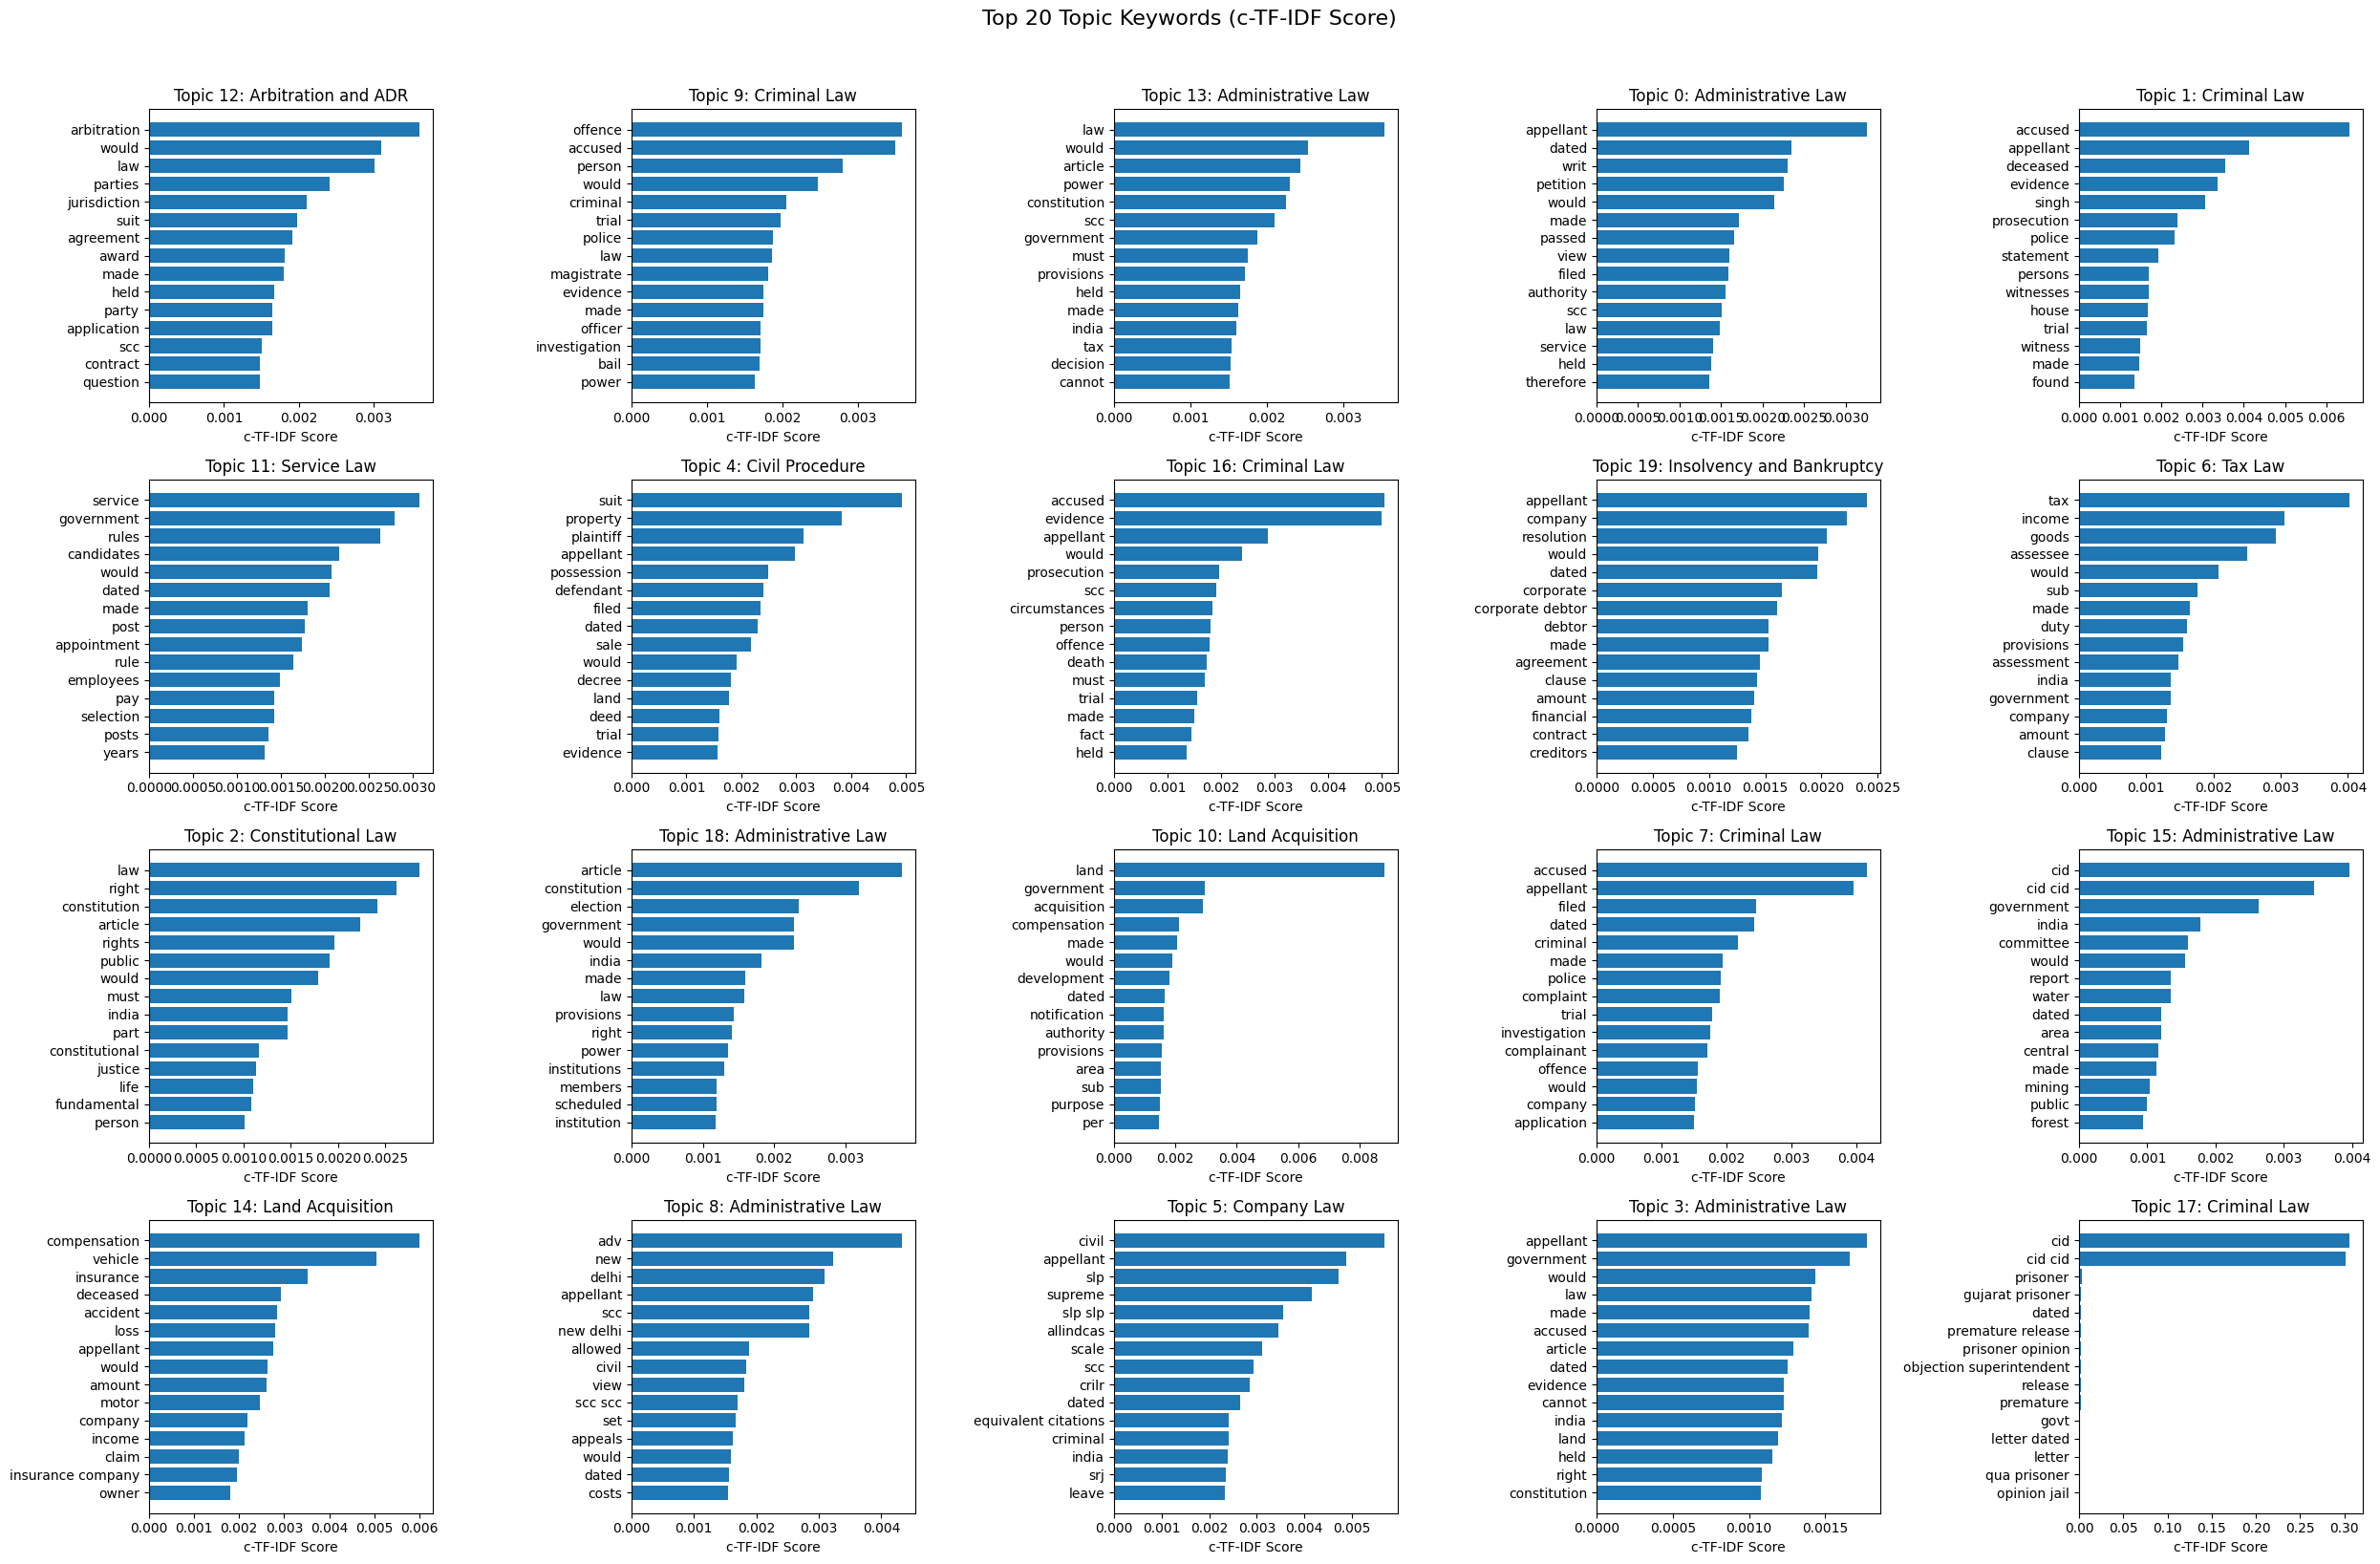

['ltm_outputs/topic_barcharts_top_20.png']

In [ ]:
ltm.plot_topic_barcharts(top_n_topics=20)

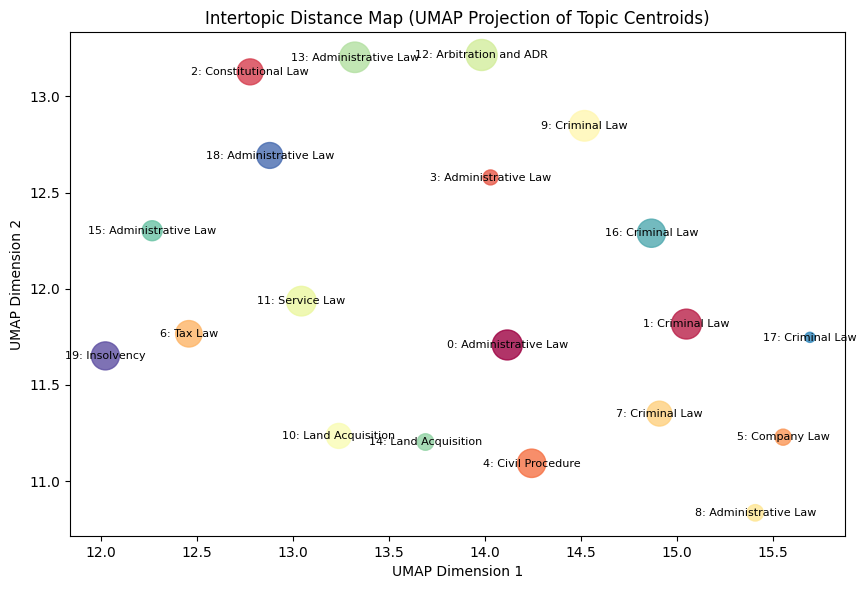

'ltm_outputs/intertopic_distance.png'

In [ ]:
ltm.plot_intertopic_distance()

In [ ]:
# Run this in your Kaggle/Training Notebook after the fit_transform call

import joblib
import os
# Assuming 'ltm_model' is your fitted LegalTopicModel instance

OUTPUT_LTM_PATH = "ltm_model_DEPLOYMENT_READY.joblib"

print("Starting FINAL model saving with 768D centroids...")
ltm_model = ltm
# CRITICAL CHECK: Must be 768 dimensions
if ltm_model.topic_centroids_.shape[1] != 768:
    raise ValueError(f"Centroid array dimension is incorrect: Expected 768, got {ltm_model.topic_centroids_.shape[1]}.")

stable_components = {
    "topic_centroids_": ltm_model.topic_centroids_,
    "topic_map": ltm_model.topic_map,
    "topic_keywords_": ltm_model.topic_keywords_,
    "model_name": ltm_model.model_name
}

joblib.dump(stable_components, OUTPUT_LTM_PATH)
print(f"🎉 Successfully created deployment-ready model file: {OUTPUT_LTM_PATH}")

# Download this file: ltm_model_DEPLOYMENT_READY.joblib

Starting FINAL model saving with 768D centroids...
🎉 Successfully created deployment-ready model file: ltm_model_DEPLOYMENT_READY.joblib
